In [1]:
# some preliminary settings and functions
import sys
sys.path.append("/home/aunai/build_phare")
sys.path.append("/home/aunai/PHARE/pyphare/")
import os
import numpy as np
import pyphare
from pyphare.pharesee.hierarchy import hierarchy_from
from pyphare.pharesee.plotting import zoom_effect
import matplotlib.pyplot as plt
from pyphare.pharesee.run import Run
from pyphare.pharesee.hierarchy import finest_field
from pyphare.pharesee.hierarchy import compute_hier_from
%matplotlib notebook

In [2]:
r = Run("/DATA/phare/pharebook_data/tests/twoStream/run010/")

In [3]:
t =10.
E = r.GetE(t)
B = r.GetB(t)
N = r.GetNi(t)

In [4]:
ex, xex = finest_field(E, "Ex", t)
ey, xey = finest_field(E, "Ey", t)
ez, xez = finest_field(E, "Ez", t)

In [5]:
bx, xbx = finest_field(B, "Bx", t)
by, xby = finest_field(B, "By", t)
bz, xbz = finest_field(B, "Bz", t)

<IPython.core.display.Javascript object>


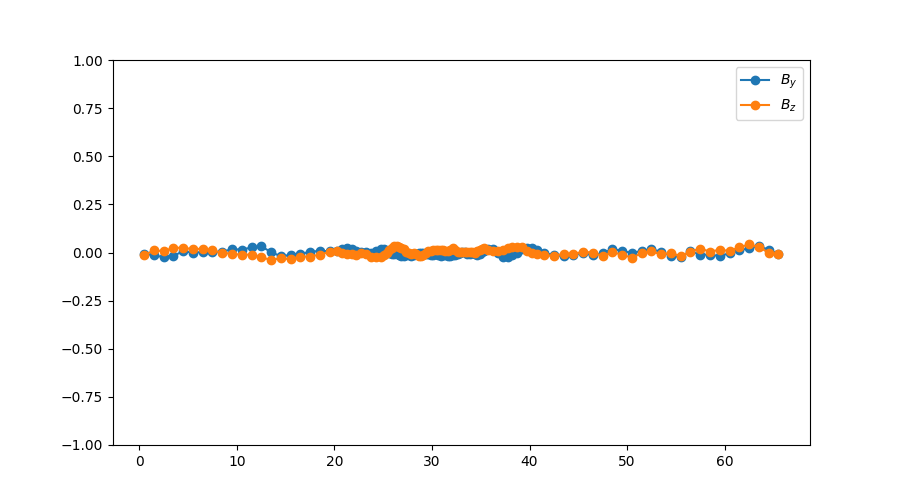

(-1.0, 1.0)

In [6]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(xby, by, marker='o', label=r"$B_y$")
ax.plot(xbz, bz, marker='o', label=r"$B_z$")
ax.legend()
ax.set_ylim((-1,1))

<IPython.core.display.Javascript object>


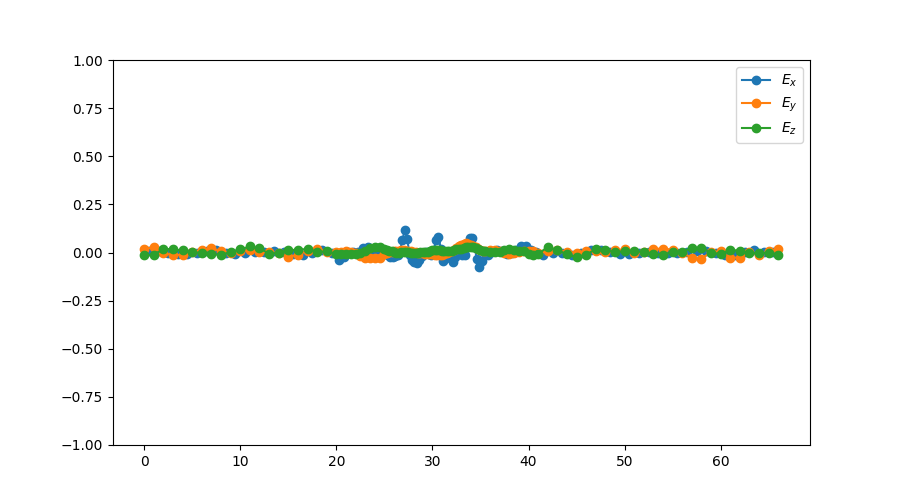

(-1.0, 1.0)

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
ax.plot(xex, ex, marker='o', label=r"$E_x$")
ax.plot(xey, ey, marker='o', label=r"$E_y$")
ax.plot(xez, ez, marker='o', label=r"$E_z$")
ax.legend()
ax.set_ylim((-1,1))

In [8]:
patches=sorted(B.patch_levels[2].patches, key=lambda p:p.box.lower[0])

In [9]:
epatches=sorted(E.patch_levels[2].patches, key=lambda p:p.box.lower[0])
npatches=sorted(N.patch_levels[2].patches, key=lambda p:p.box.lower[0])

<IPython.core.display.Javascript object>


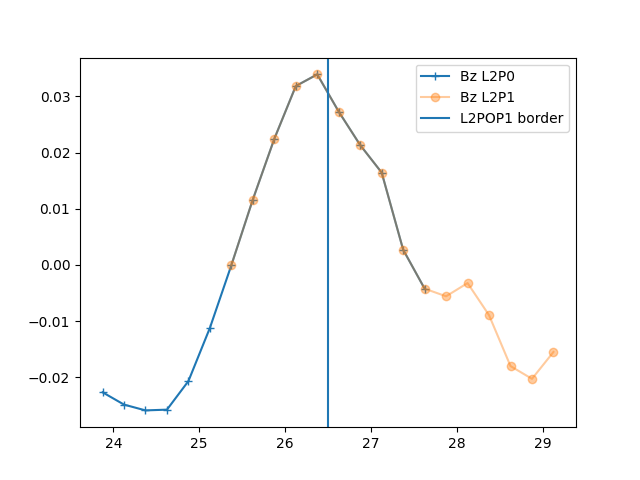

In [10]:
fig, ax = plt.subplots()
ax.plot(patches[0].patch_datas["Bz"].x,patches[0].patch_datas["Bz"].dataset[:],
        marker="+", label="Bz L2P0")
ax.plot(patches[1].patch_datas["Bz"].x, patches[1].patch_datas["Bz"].dataset[:],
        marker="o", alpha=0.4, label="Bz L2P1")
ax.axvline(patches[1].patch_datas["Bz"].x[5]-patches[0].layout.dl[0]/2, label="L2POP1 border")
ax.legend()

<IPython.core.display.Javascript object>


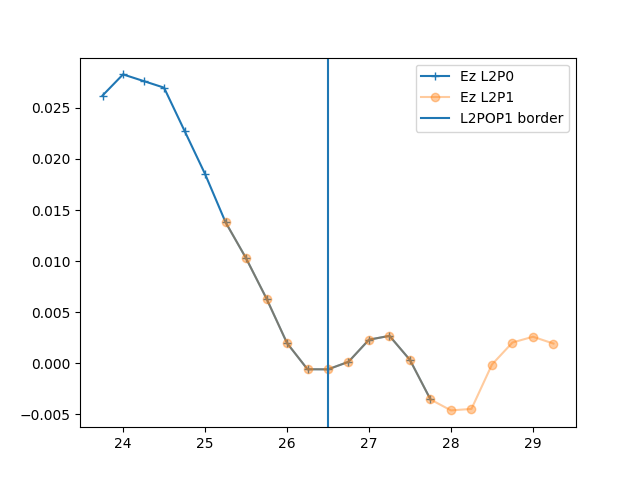

In [11]:
fig, ax = plt.subplots()
ax.plot(epatches[0].patch_datas["Ez"].x,epatches[0].patch_datas["Ez"].dataset[:],
        marker="+", label="Ez L2P0")
ax.plot(epatches[1].patch_datas["Ez"].x, epatches[1].patch_datas["Ez"].dataset[:],
        marker="o", alpha=0.4, label="Ez L2P1")
ax.axvline(epatches[1].patch_datas["Ez"].x[5], label="L2POP1 border")
ax.legend()

<IPython.core.display.Javascript object>


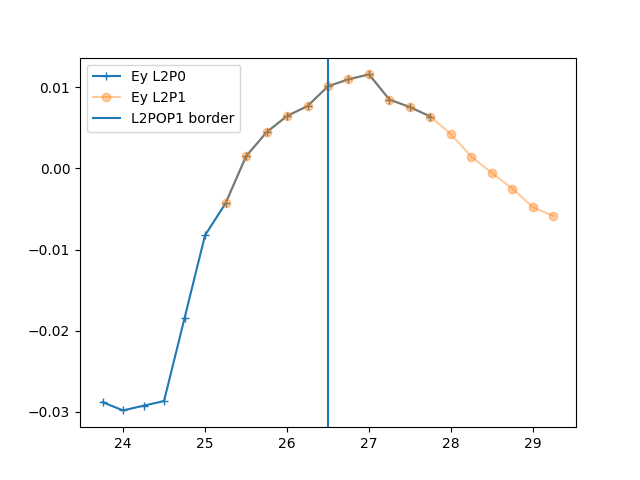

In [12]:
fig, ax = plt.subplots()
ax.plot(epatches[0].patch_datas["Ey"].x,epatches[0].patch_datas["Ey"].dataset[:],
        marker="+", label="Ey L2P0")
ax.plot(epatches[1].patch_datas["Ey"].x, epatches[1].patch_datas["Ey"].dataset[:],
        marker="o", alpha=0.4, label="Ey L2P1")
ax.axvline(epatches[1].patch_datas["Ey"].x[5], label="L2POP1 border")
ax.legend()

<IPython.core.display.Javascript object>


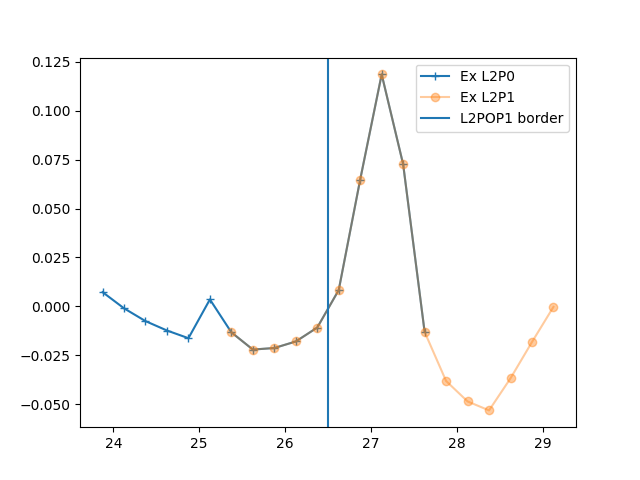

In [13]:
fig, ax = plt.subplots()
ax.plot(epatches[0].patch_datas["Ex"].x,epatches[0].patch_datas["Ex"].dataset[:],
        marker="+", label="Ex L2P0")
ax.plot(epatches[1].patch_datas["Ex"].x, epatches[1].patch_datas["Ex"].dataset[:],
        marker="o", alpha=0.4, label="Ex L2P1")
ax.axvline(epatches[1].patch_datas["Ex"].x[5]-epatches[1].layout.dl[0]/2., label="L2POP1 border")
ax.legend()

In [14]:
npatches[0].patch_datas.keys()

dict_keys(['rho'])

In [15]:
[p.box.nCells() for p in epatches]

[6, 6, 10, 8, 6, 6]

<IPython.core.display.Javascript object>


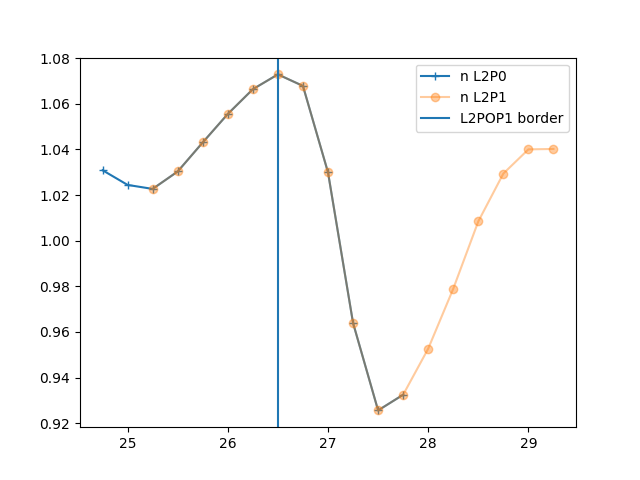

In [16]:
fig, ax = plt.subplots()
ax.plot(npatches[0].patch_datas["rho"].x, npatches[0].patch_datas["rho"].dataset[:],
        marker="+", label="n L2P0")
ax.plot(npatches[1].patch_datas["rho"].x, npatches[1].patch_datas["rho"].dataset[:],
        marker="o", alpha=0.4, label="n L2P1")
ax.axvline(npatches[1].patch_datas["rho"].x[5], label="L2POP1 border")
ax.legend()

In [17]:
t = 10
NN = r.GetNi(t)
EE = r.GetE(t)
ex, xex = finest_field(EE, "Ex", t)
ey, xey = finest_field(EE, "Ey", t)
ez, xez = finest_field(EE, "Ez", t)
n,xn = finest_field(NN, "rho")

<IPython.core.display.Javascript object>


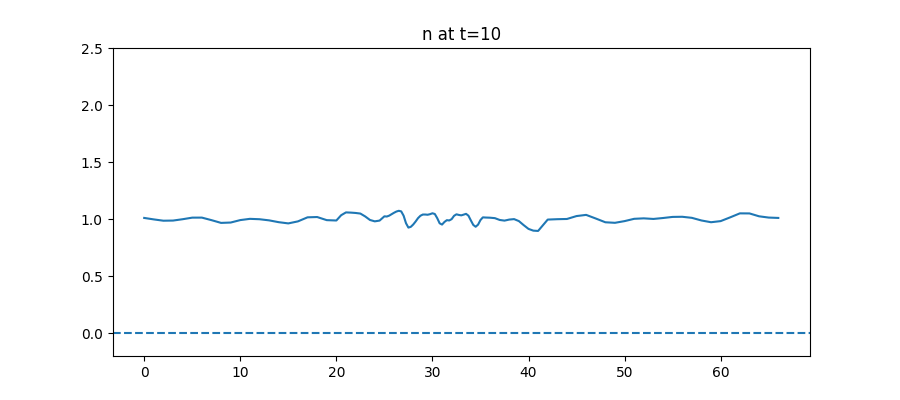

In [20]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(xn, n)
ax.set_title("n at t={}".format(t))
ax.set_ylim((-0.2,2.5))
ax.axhline(0, ls="--")

In [19]:
 np.arange(0, 100, 0.05).size

2000

<IPython.core.display.Javascript object>


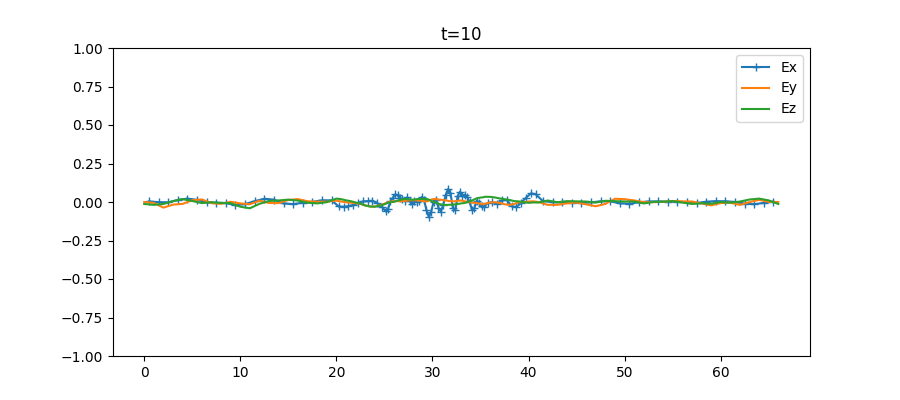

(-1.0, 1.0)

In [20]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(xex, ex, label="Ex", marker="+")
ax.plot(xey, ey, label="Ey")
ax.plot(xez, ez, label="Ez")
ax.set_title("t={}".format(t))
ax.legend()
ax.set_ylim((-1,1))

In [127]:
def filter_bi(qty, alpha=0.5, passes=1):
    n = qty.size
    for p in np.arange(passes):
        for i in np.arange(1,n-1):
            qty[i] = alpha*qty[i] + (1-alpha)*(qty[i-1] + qty[i+1])/2
    return qty

In [131]:
nn = filter_bi(n.copy(), passes=10)  

<IPython.core.display.Javascript object>


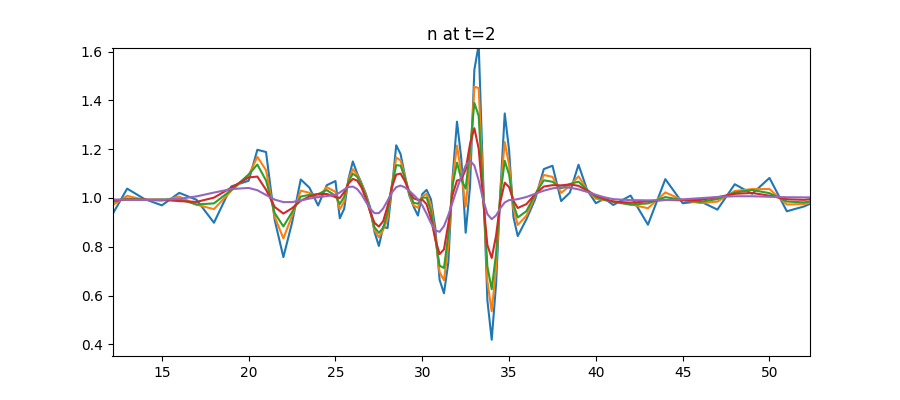

In [134]:
fig, ax = plt.subplots(figsize=(9,4))
ax.plot(xn, n)
ax.plot(xn, filter_bi(n.copy(), passes=1))
ax.plot(xn, filter_bi(n.copy(), passes=2))
ax.plot(xn, filter_bi(n.copy(), passes=4))
ax.plot(xn, filter_bi(n.copy(), passes=10))
ax.set_title("n at t={}".format(t))
ax.set_ylim((-0.2,2.5))
ax.axhline(0, ls="--")

In [32]:
B.patch_levels[2].patches[0].patch_datas["Bz"].dataset[:]

array([ 0.03590471,  0.03106585,  0.02532582,  0.0186846 ,  0.01123489,
        0.00764183, -0.00992375, -0.0156417 , -0.02299329, -0.03317327,
       -0.04578607, -0.04549733, -0.04275586, -0.03563093, -0.03229849,
        0.7797129 ], dtype=float32)

<IPython.core.display.Javascript object>


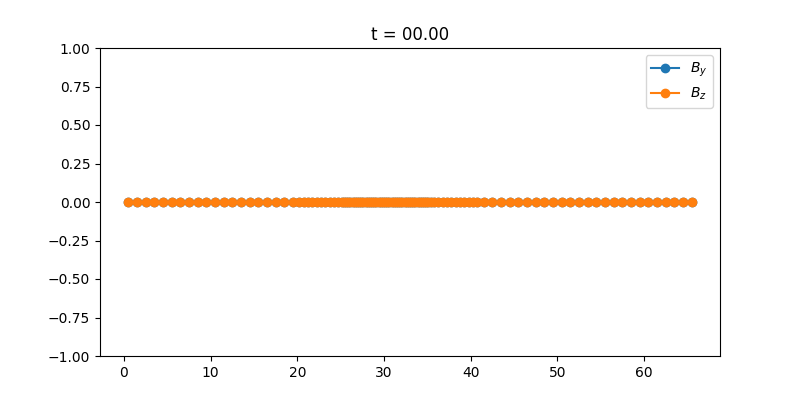

<IPython.core.display.Javascript object>


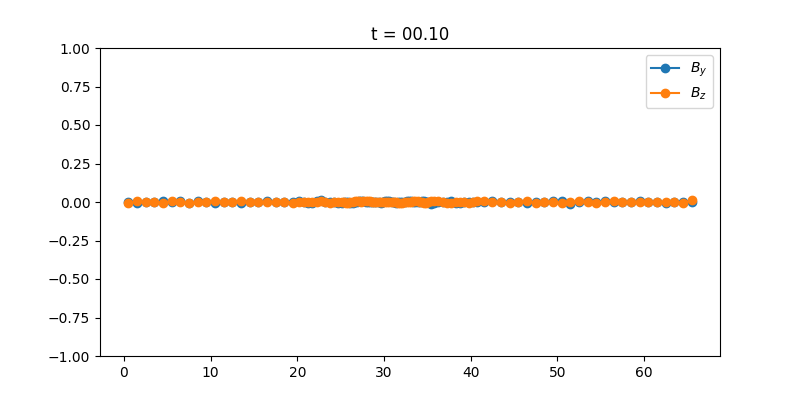

<IPython.core.display.Javascript object>


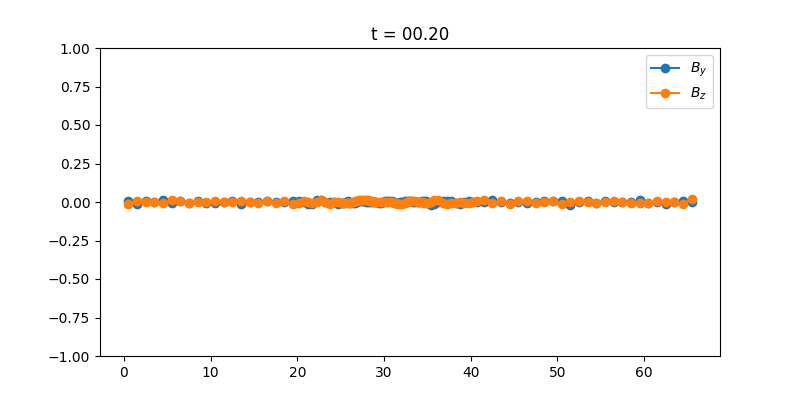

<IPython.core.display.Javascript object>


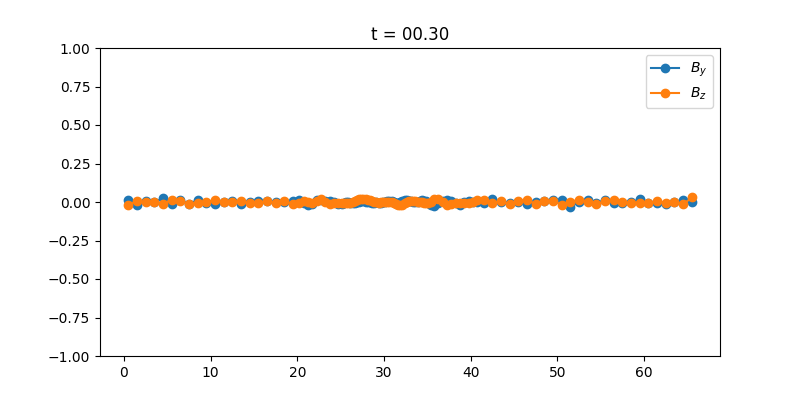

<IPython.core.display.Javascript object>


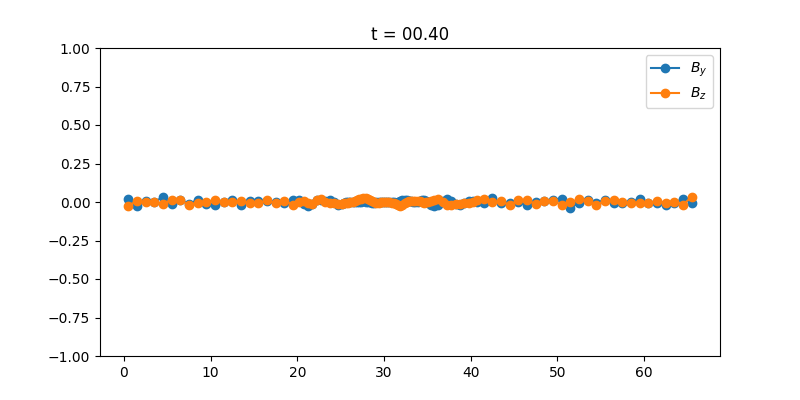

<IPython.core.display.Javascript object>


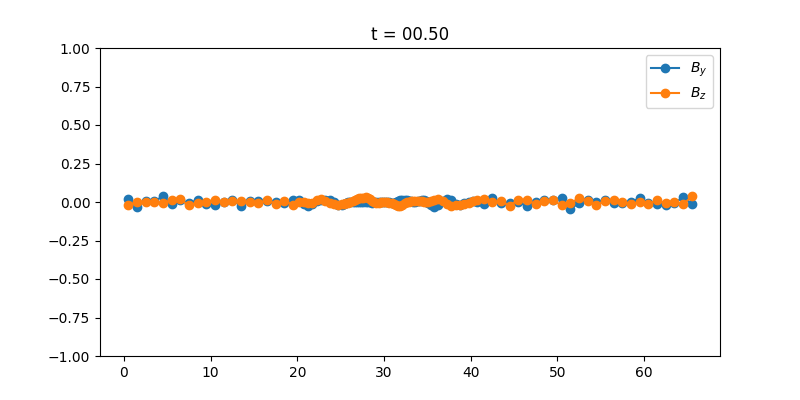

<IPython.core.display.Javascript object>


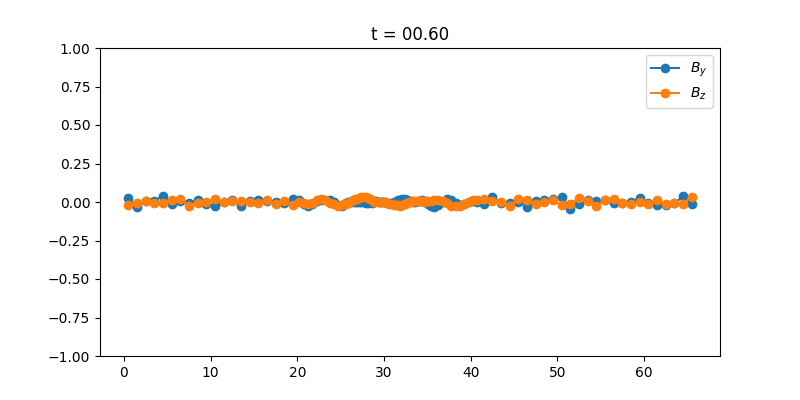

<IPython.core.display.Javascript object>


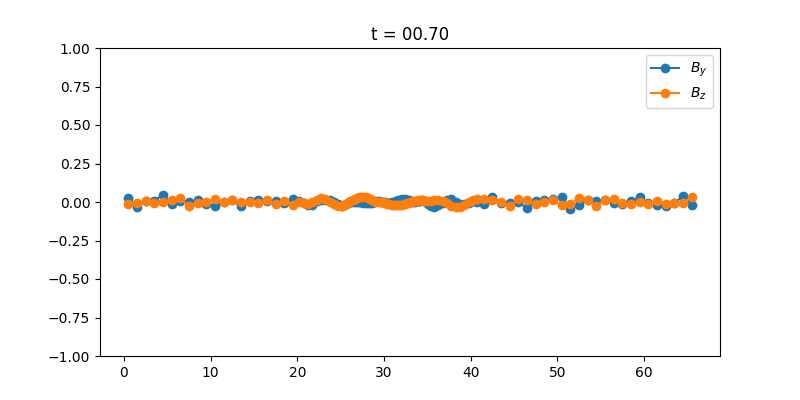

<IPython.core.display.Javascript object>


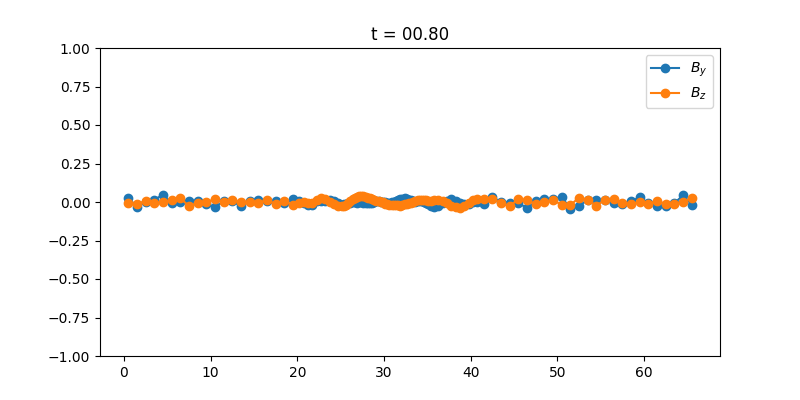

<IPython.core.display.Javascript object>


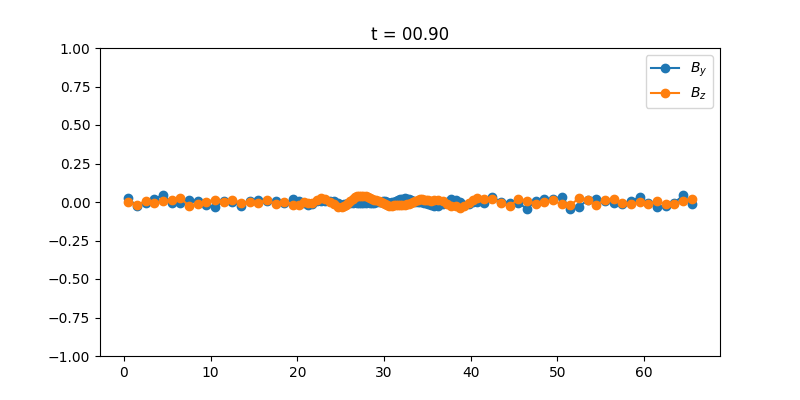

<IPython.core.display.Javascript object>


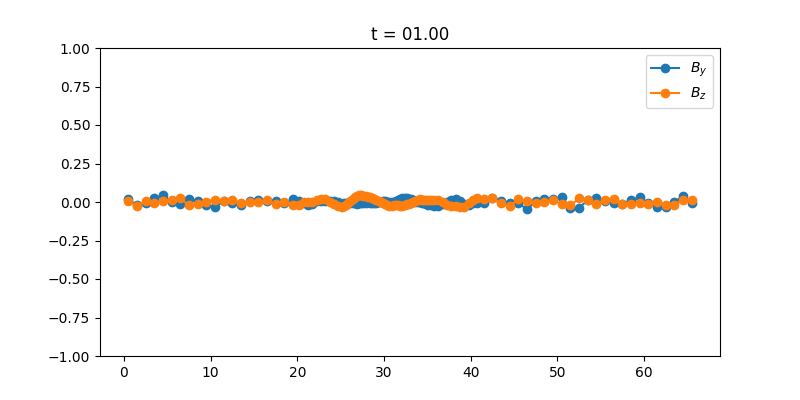

<IPython.core.display.Javascript object>


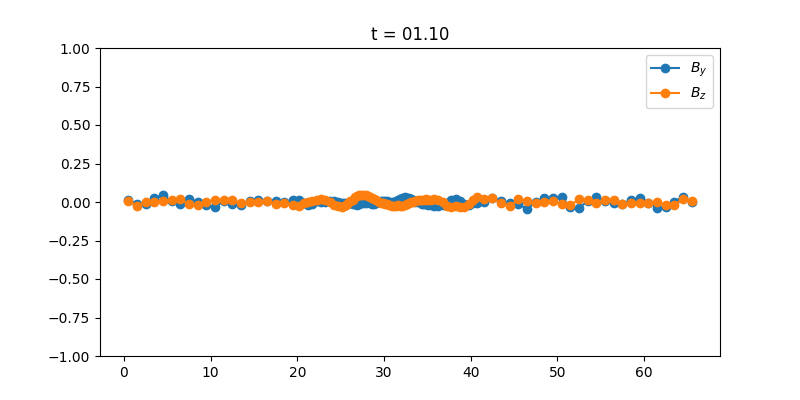

<IPython.core.display.Javascript object>


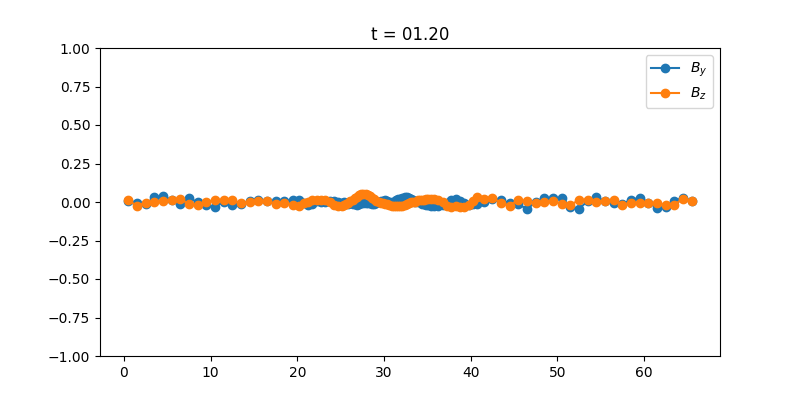

<IPython.core.display.Javascript object>


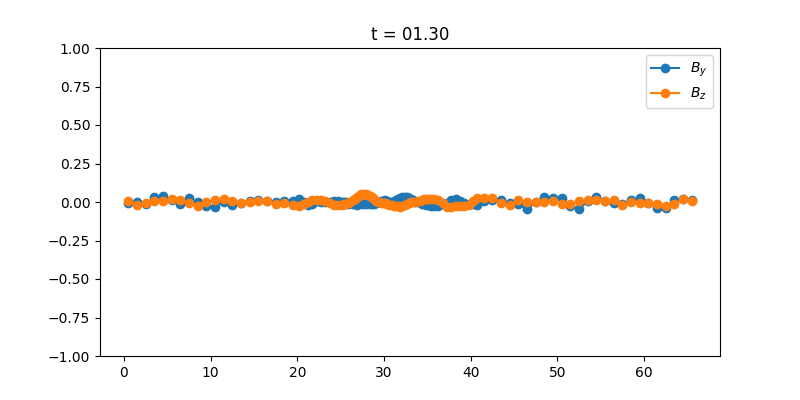

<IPython.core.display.Javascript object>


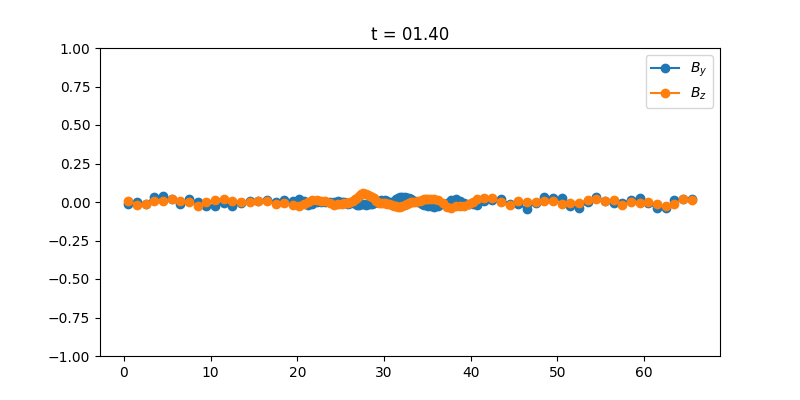

<IPython.core.display.Javascript object>


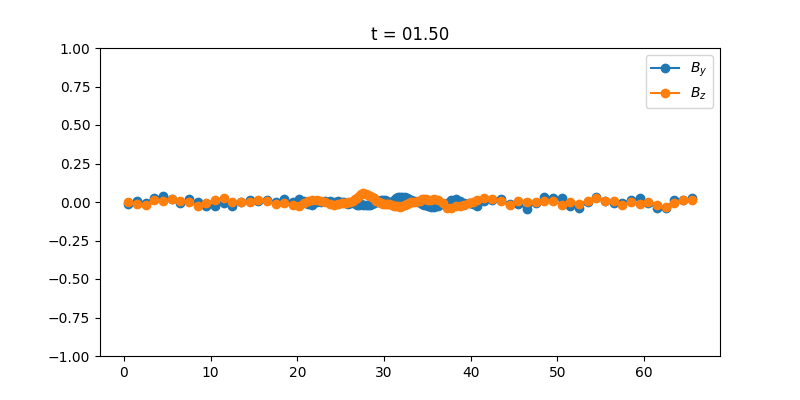

<IPython.core.display.Javascript object>


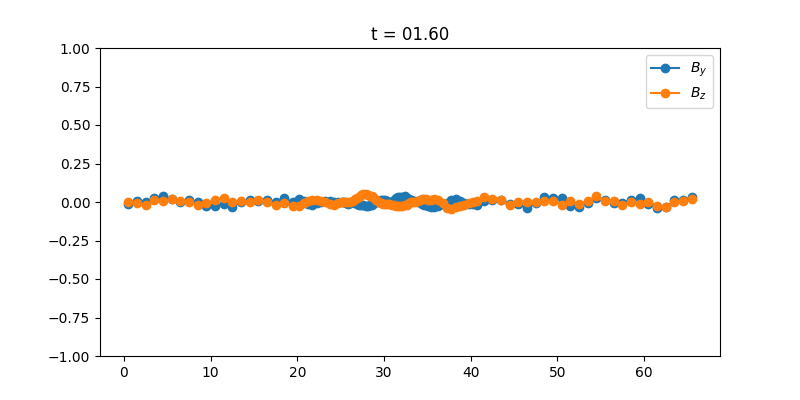

<IPython.core.display.Javascript object>


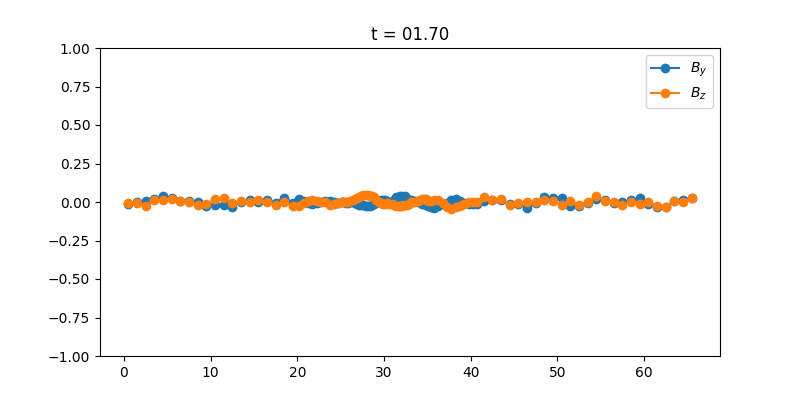

<IPython.core.display.Javascript object>


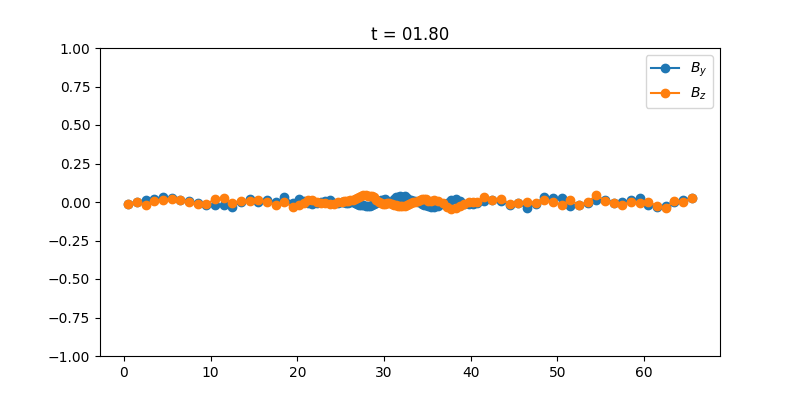

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


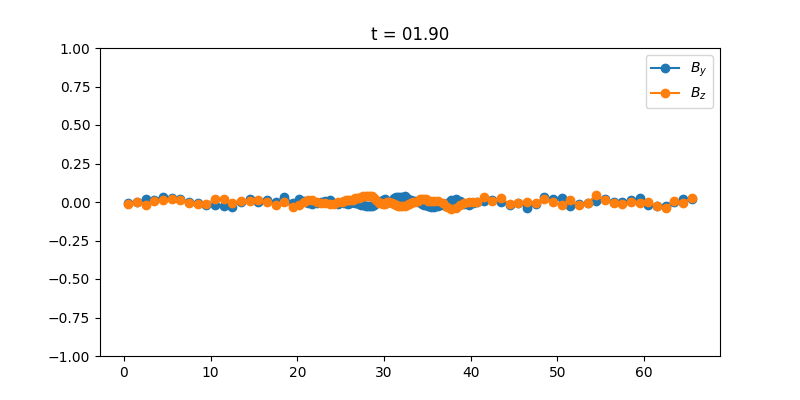

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


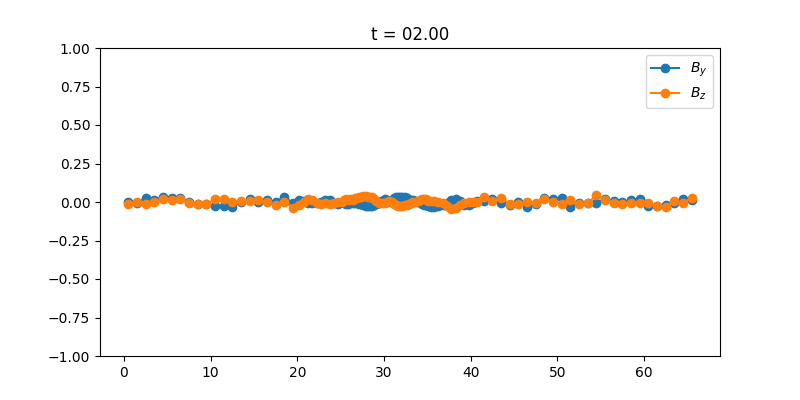

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


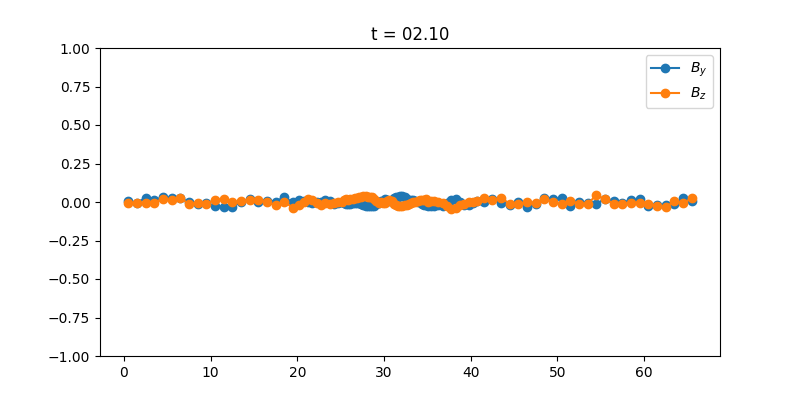

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


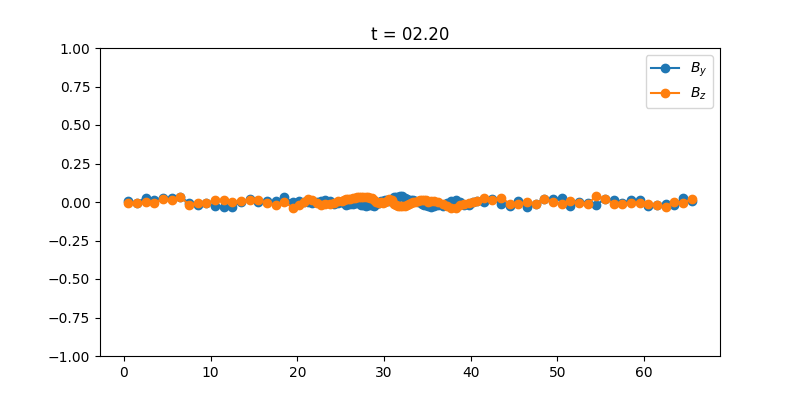

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


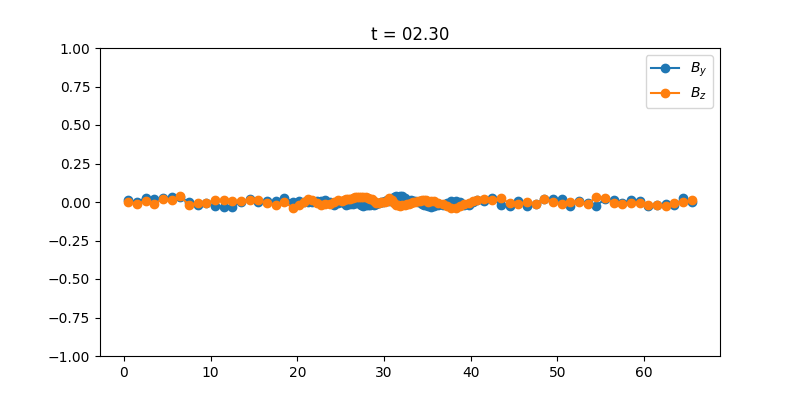

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


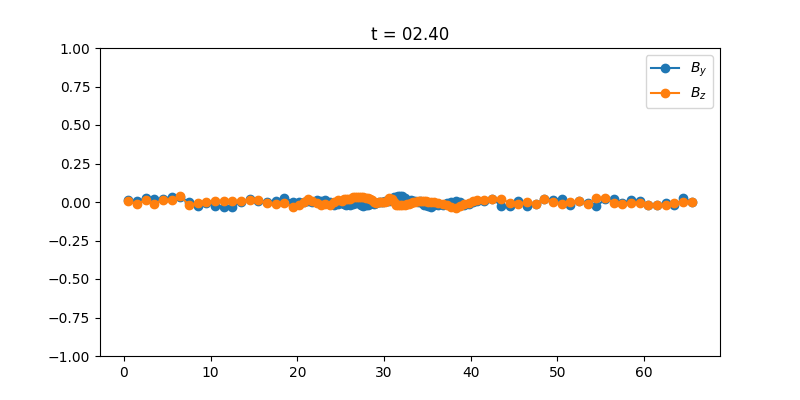

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


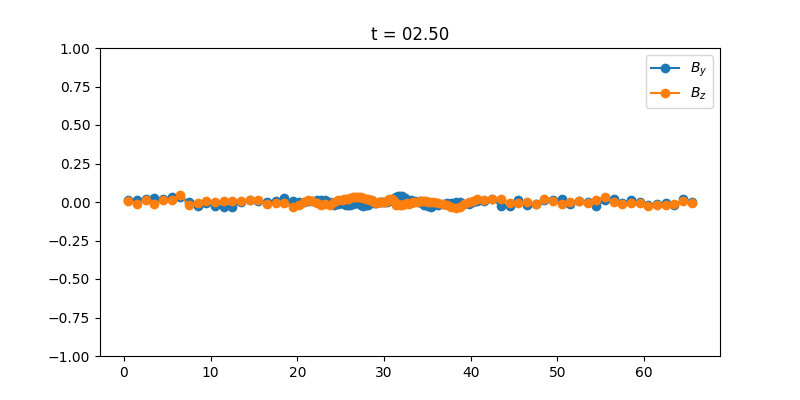

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


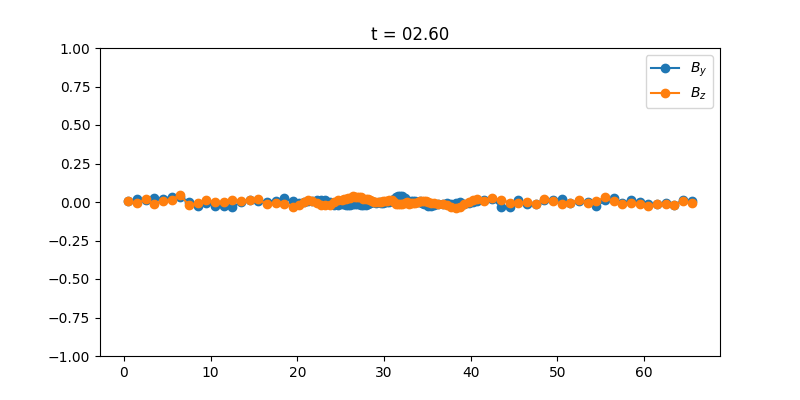

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


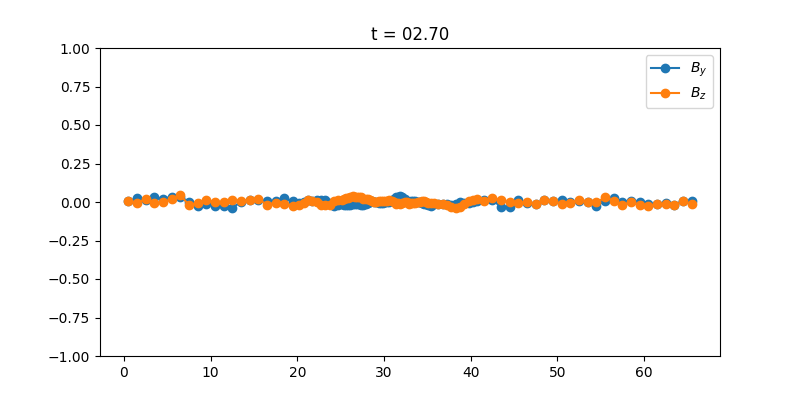

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


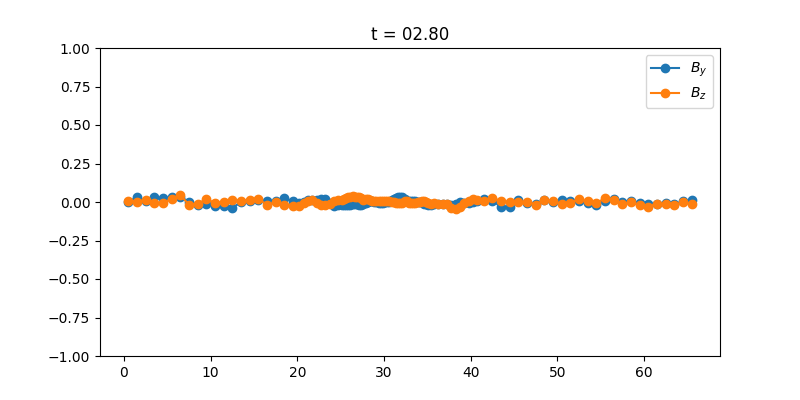

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


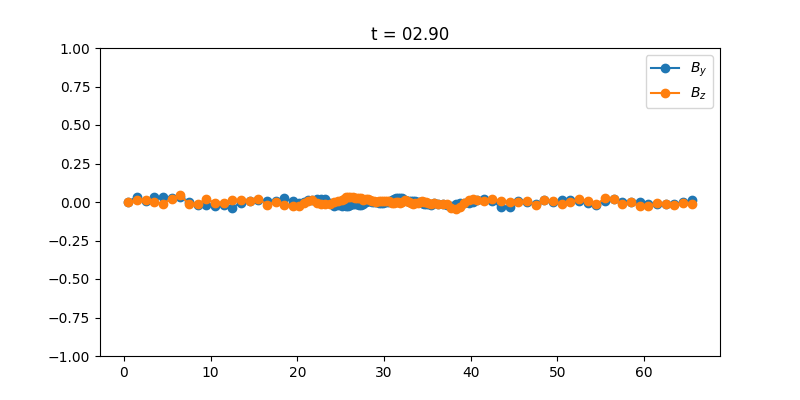

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


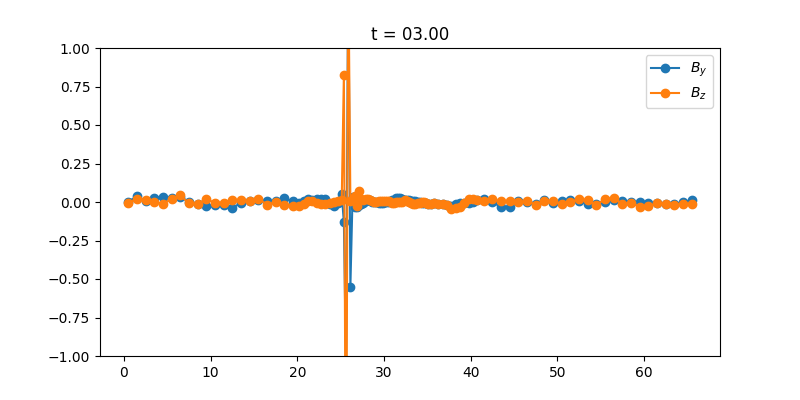

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


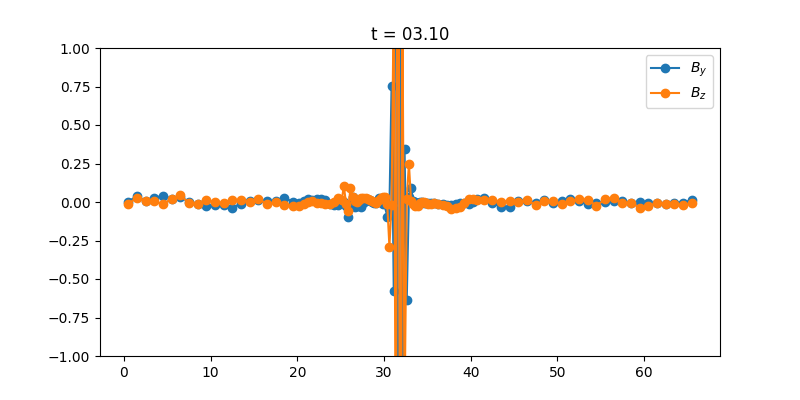

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


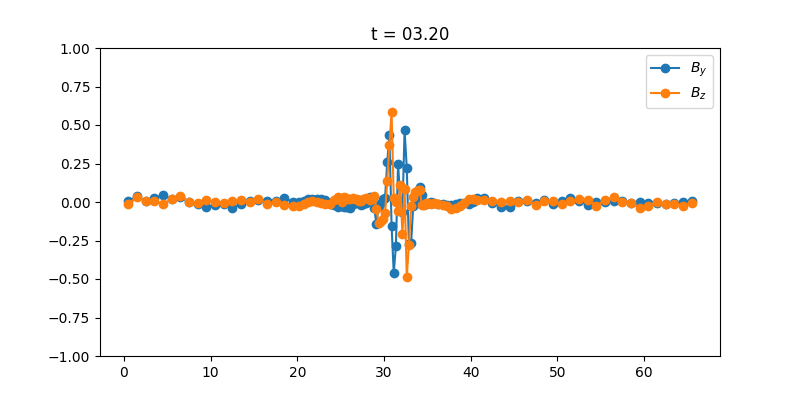

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


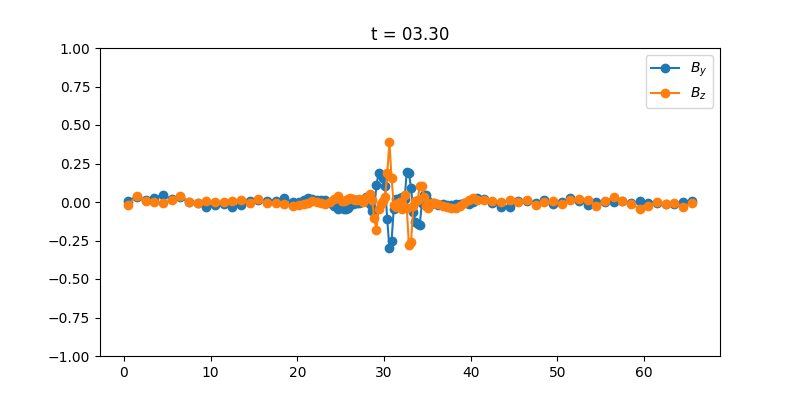

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


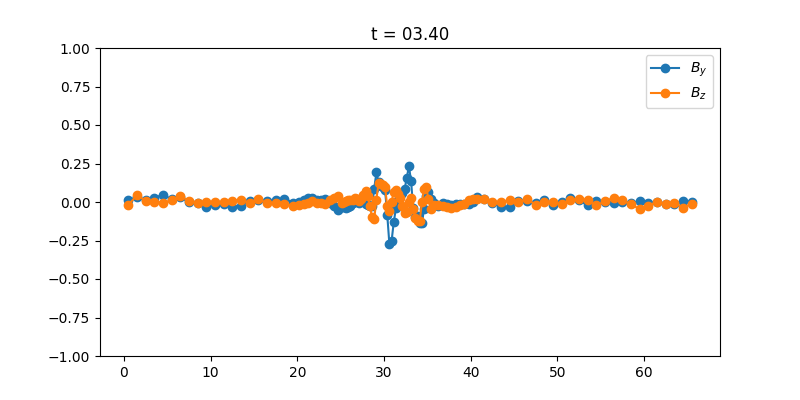

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


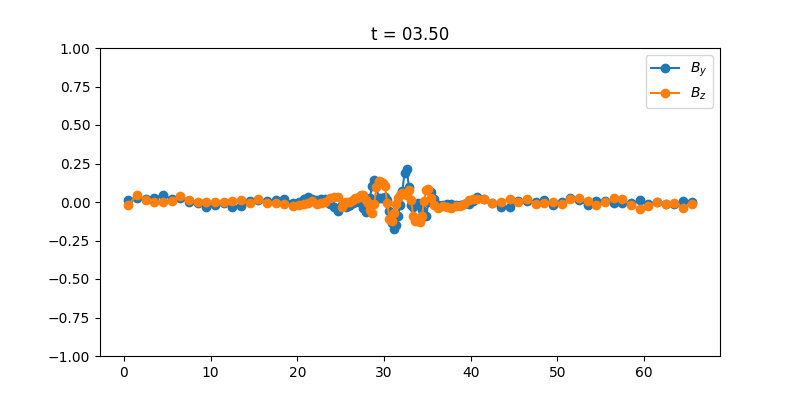

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


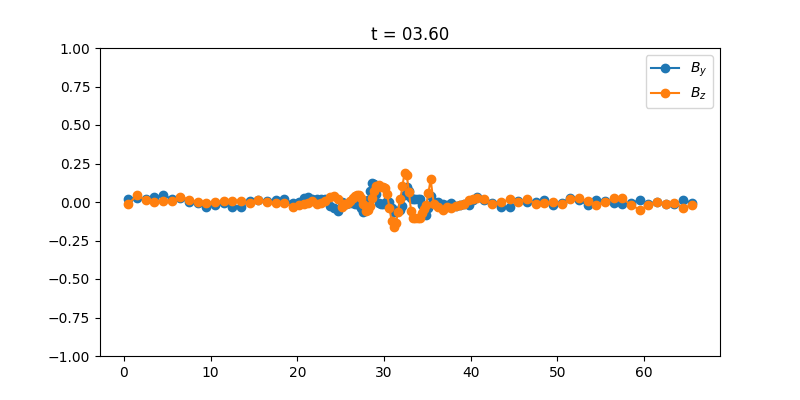

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


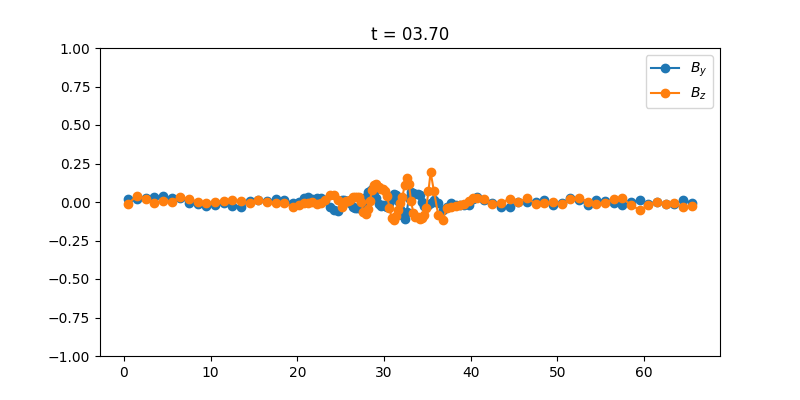

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


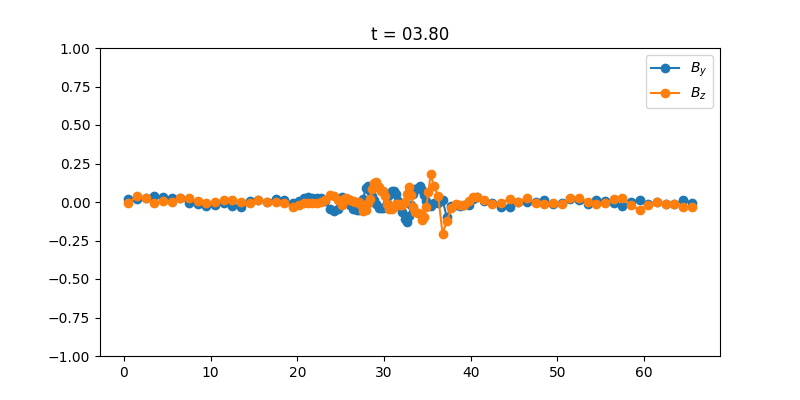

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


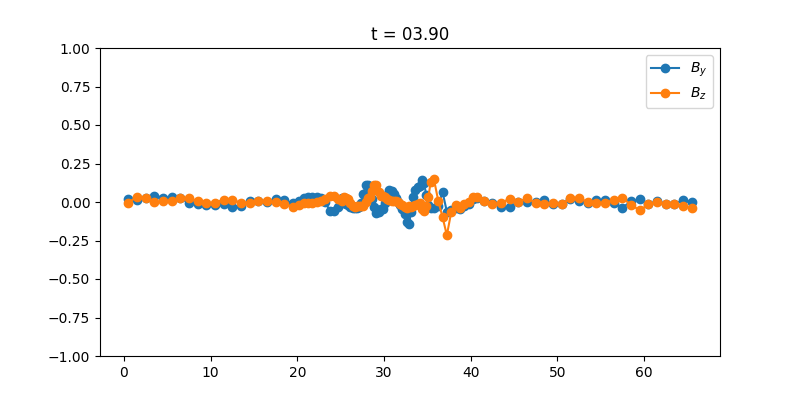

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


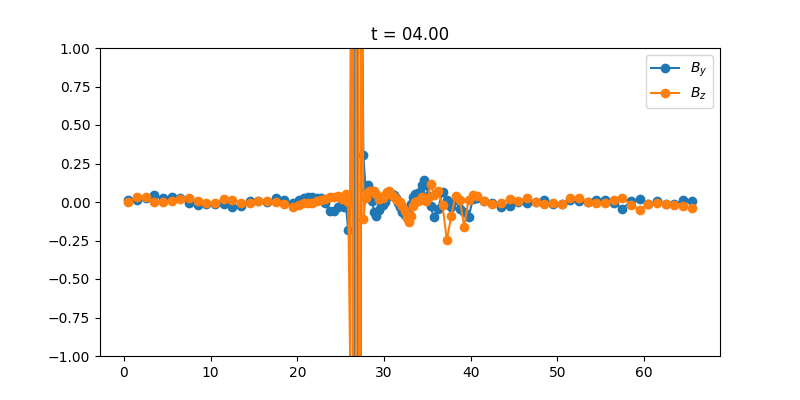

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


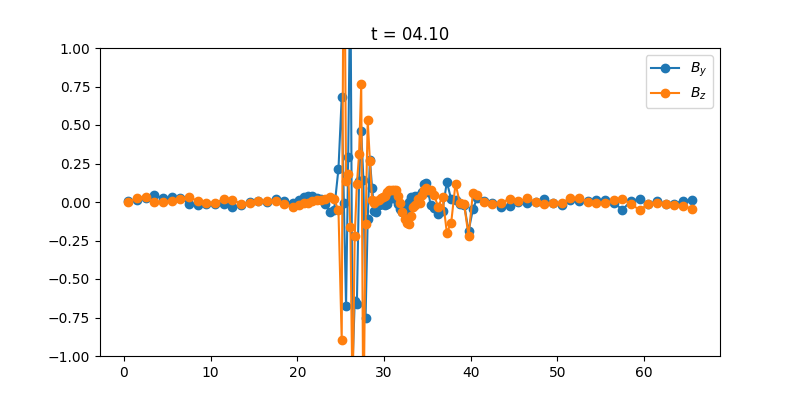

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


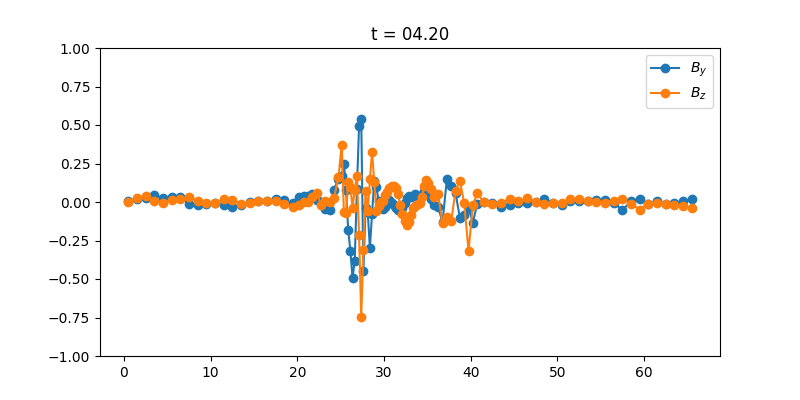

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


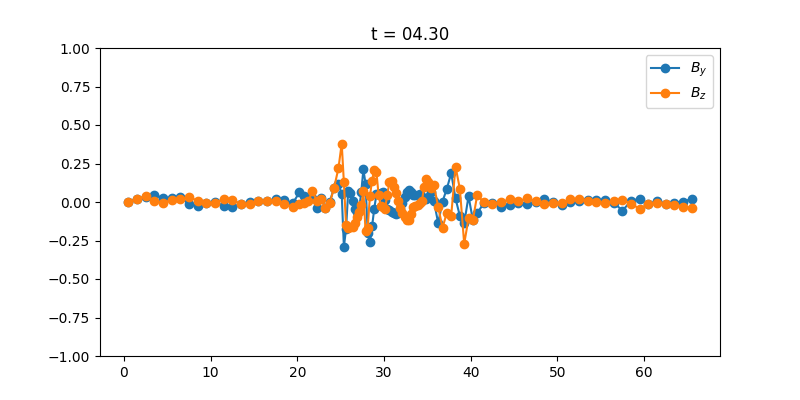

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


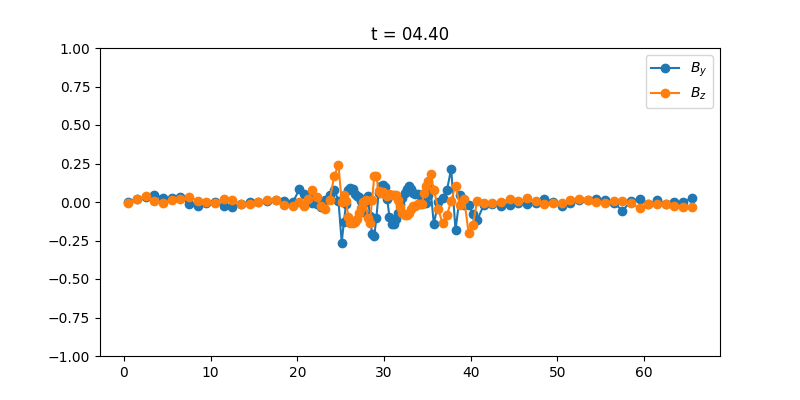

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


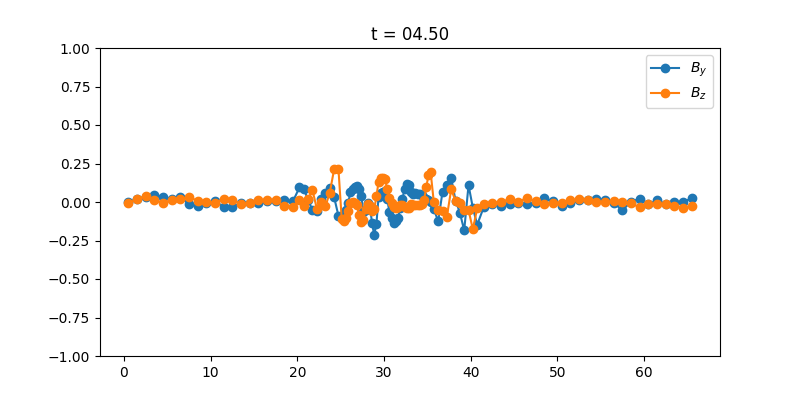

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


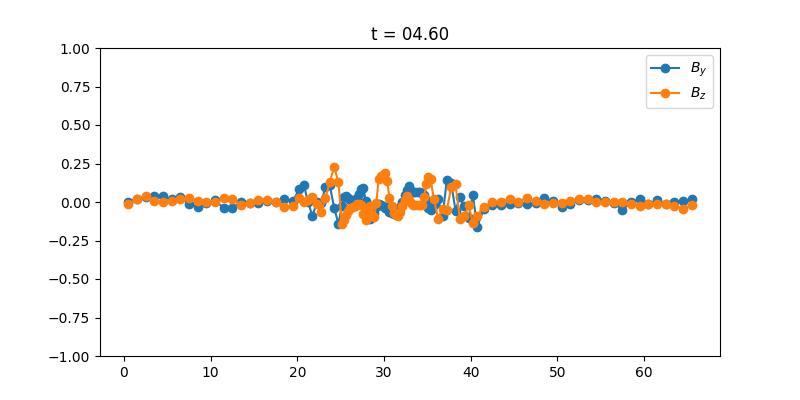

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


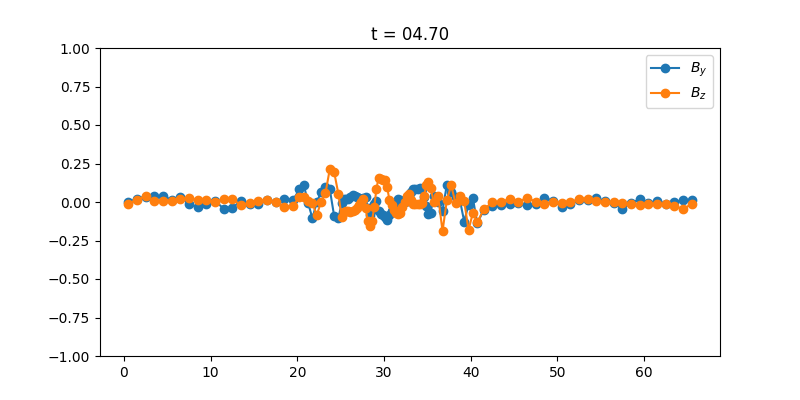

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


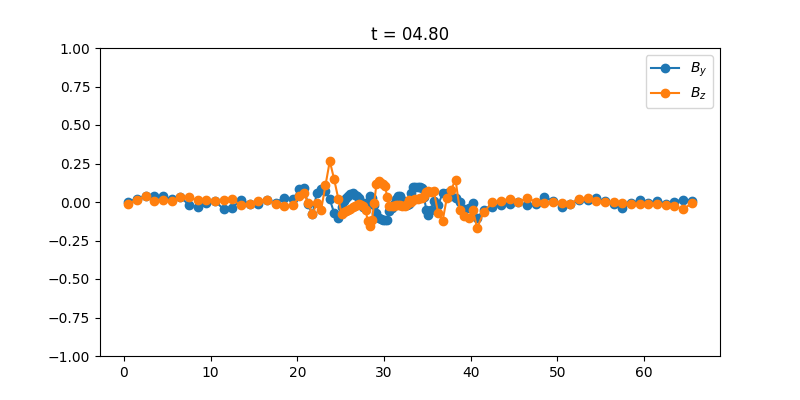

<ipython-input-64-0dd434a08b06>:3: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots(figsize=(8,4))


<IPython.core.display.Javascript object>


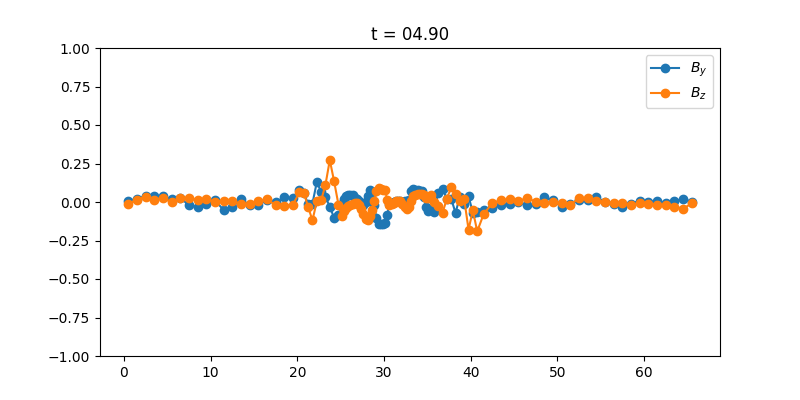

In [64]:
for it,t in enumerate(np.arange(50)*0.1):
    B = r.GetB(t)
    fig, ax = plt.subplots(figsize=(8,4))
    by, xby = finest_field(B, "By", t)
    bz, xbz = finest_field(B, "Bz", t)    
    ax.plot(xby, by, marker='o', label=r"$B_y$")
    ax.plot(xbz, bz, marker='o', label=r"$B_z$")
    ax.legend()
    ax.set_ylim((-1,1))
    ax.set_title("t = {:05.2f}".format(t))
    fig.savefig("twoStreamNuts_{:04d}.png".format(it))